In [1]:
import os
import gc
import cv2
import json
import scipy.ndimage as ndimage
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, auc, 
                             balanced_accuracy_score)
import tensorflow as tf
from tensorflow.keras import mixed_precision


# --- ENVIRONMENT SETUP ---
# Enable Mixed Precision for Performance (Nhanh hơn trên GPU T4/P100/V100)
try:
    mixed_precision.set_global_policy('mixed_float16')
    print("✅ Mixed Precision Enabled")
except:
    pass

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --- CONFIGURATION CLASS ---
class Config:
    def __init__(self):
        # Paths (Nên sửa lại path nếu chạy trên môi trường khác Kaggle)
        self.BASE_PATH = "/kaggle/input/skin-cancer-mnist-ham10000" 
        self.MODEL_SAVE_DIR = "./saved_models"
        
        # Data Parameters
        self.IMG_SIZE = 320
        self.BATCH_SIZE = 16
        self.SEED = 42
        self.TEST_SIZE = 0.2
        self.VAL_SIZE = 0.15 # Của tập train sau khi split test
        
        # Training Parameters
        self.EPOCHS = 40
        self.LEARNING_RATE = 1e-4
        self.FOCAL_LOSS_GAMMA = 2.0
        self.FOCAL_LOSS_ALPHA = None
        
        # Regularization & Architecture
        self.DROPOUT_RATE = 0.4 
        self.L2_WEIGHT_DECAY = 1e-4
        
        # Augmentation Settings
        self.CUTOUT_SIZE = 24  
        
        # Ensembling
        self.BACKBONES = ["ResNet50"]

    def create_dirs(self):
        if not os.path.exists(self.MODEL_SAVE_DIR):
            os.makedirs(self.MODEL_SAVE_DIR)
            print(f"📁 Created directory: {self.MODEL_SAVE_DIR}")

cfg = Config()
cfg.create_dirs()

2025-12-24 06:23:01.512218: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766557381.713311      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766557381.774009      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766557382.263315      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766557382.263375      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766557382.263378      24 computation_placer.cc:177] computation placer alr

✅ Mixed Precision Enabled
📁 Created directory: ./saved_models


In [2]:
def plot_training_history(histories: dict, save_dir: str = None):
    """
    Vẽ biểu đồ Loss và Accuracy cho tất cả các model đã train.
    Trục y được scale từ 0 đến 1.
    """
    for model_name, history in histories.items():
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        axes[0].plot(history['loss'], label='Train Loss')
        axes[0].plot(history['val_loss'], label='Val Loss')
        axes[0].set_title(f'{model_name} - Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_ylim(0, 1)     
        axes[0].legend()
        axes[0].grid(True)
        
        # Accuracy
        axes[1].plot(history['accuracy'], label='Train Acc')
        axes[1].plot(history['val_accuracy'], label='Val Acc')
        axes[1].set_title(f'{model_name} - Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_ylim(0, 1)     
        axes[1].legend()
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.show()


def plot_confusion_matrix_custom(y_true, y_pred_idx, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred_idx)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_multiclass_roc(y_true, y_pred_proba, classes, title="ROC Curves"):
    """
    Vẽ ROC cho từng lớp (One-vs-Rest strategy).
    """
    n_classes = len(classes)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # One-hot encoding y_true cho việc tính toán ROC
    y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=n_classes)
    
    plt.figure(figsize=(12, 8))
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], lw=2, 
                 label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

In [3]:
def load_metadata(cfg: Config):
    """Load metadata và map đường dẫn ảnh."""
    image_path = {os.path.splitext(os.path.basename(x))[0]: x
                  for x in glob(os.path.join(cfg.BASE_PATH, '*', '*.jpg'))}
    
    df = pd.read_csv(os.path.join(cfg.BASE_PATH, 'HAM10000_metadata.csv'))
    df['path'] = df['image_id'].map(image_path.get)
    df['cell_type_idx'] = pd.Categorical(df['dx']).codes
    
    # Tạo mapping label
    idx_to_label = {i: label for i, label in enumerate(df['dx'].astype('category').cat.categories)}
    
    return df, idx_to_label

def balance_data_by_duplication(df: pd.DataFrame, target_column='dx'):
    """
    Cân bằng dữ liệu bằng cách DUPLICATE các dòng của lớp thiểu số.
    Khi qua Augmentation pipeline, các ảnh trùng lặp này sẽ thành các biến thể khác nhau.
    """
    max_count = df[target_column].value_counts().max()
    balanced_dfs = []
    
    print("--- Data Balancing Statistics ---")
    for label, group in df.groupby(target_column):
        count = len(group)
        if count < max_count:
            n_repeats = max_count // count
            remainder = max_count % count
            upsampled_group = pd.concat([group] * n_repeats + [group.head(remainder)], axis=0)
            balanced_dfs.append(upsampled_group)
            print(f"Class '{label}': Upsampled form {count} -> {len(upsampled_group)}")
        else:
            balanced_dfs.append(group)
            print(f"Class '{label}': Kept original {count}")
            
    final_df = pd.concat(balanced_dfs, axis=0).sample(frac=1.0, random_state=42).reset_index(drop=True)
    return final_df

# --- EXECUTE DATA LOADING ---
df, idx_to_label = load_metadata(cfg)
num_classes = len(idx_to_label)

# Stratified Split
train_df_raw, test_df = train_test_split(
    df, test_size=cfg.TEST_SIZE, stratify=df['cell_type_idx'], random_state=cfg.SEED
)
train_df_raw, val_df = train_test_split(
    train_df_raw, test_size=cfg.VAL_SIZE, stratify=train_df_raw['cell_type_idx'], random_state=cfg.SEED
)

# Apply Balancing
print("\nApplying Balancing Logic...")
train_df_balanced = balance_data_by_duplication(train_df_raw)

print(f"\nFinal Dataset Shapes:")
print(f"Train (Balanced): {train_df_balanced.shape}")
print(f"Validation:       {val_df.shape}")
print(f"Test:             {test_df.shape}")


Applying Balancing Logic...
--- Data Balancing Statistics ---
Class 'akiec': Upsampled form 223 -> 4559
Class 'bcc': Upsampled form 349 -> 4559
Class 'bkl': Upsampled form 747 -> 4559
Class 'df': Upsampled form 78 -> 4559
Class 'mel': Upsampled form 757 -> 4559
Class 'nv': Kept original 4559
Class 'vasc': Upsampled form 97 -> 4559

Final Dataset Shapes:
Train (Balanced): (31913, 9)
Validation:       (1202, 9)
Test:             (2003, 9)


In [4]:
# --- CUSTOM LOSS FUNCTION ---
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=None, from_logits=False, **kwargs): # Alpha None by default
        super(FocalLoss, self).__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        
        # Calculate weight
        weight = tf.math.pow((1 - y_pred), self.gamma)
        if self.alpha is not None:
            weight = weight * self.alpha
            
        return tf.reduce_sum(weight * cross_entropy, axis=-1)

In [5]:
# ==========================================
# 1. OPTIMIZED AUGMENTATION (GPU-FRIENDLY OPS)
# ==========================================
@tf.function
def augment_image(image, label, img_size, cutout_size):
    """
    Hàm Augmentation sử dụng các phép toán TensorFlow thuần (tf.image).
    Điều này cho phép chạy song song trên nhiều luồng CPU (hoặc GPU nếu map đúng cách).
    """
    # 1. Geometric
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    # --- TRANSLATION (Pad + Random Crop) ---
    # Dịch chuyển ảnh bằng cách mở rộng biên và cắt ngẫu nhiên
    pad_amount = tf.cast(tf.cast(img_size, tf.float32) * 0.2, tf.int32) # 20%
    padded_size = img_size + pad_amount
    
    image = tf.image.resize_with_crop_or_pad(image, padded_size, padded_size)
    image = tf.image.random_crop(image, size=[img_size, img_size, 3])
    # -------------------------------------------

    # 2. Color
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    
    # 3. Rotation (90, 180, 270 degrees)
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    
    # 4. Cutout (Black Fill)
    if tf.random.uniform([]) > 0.5:
        img_h, img_w = img_size, img_size
        
        # Random center
        cut_h = tf.random.uniform([], minval=0, maxval=img_h, dtype=tf.int32)
        cut_w = tf.random.uniform([], minval=0, maxval=img_w, dtype=tf.int32)
        
        dy, dx = cutout_size // 2, cutout_size // 2
        
        y1 = tf.clip_by_value(cut_h - dy, 0, img_h)
        x1 = tf.clip_by_value(cut_w - dx, 0, img_w)
        y2 = tf.clip_by_value(cut_h + dy, 0, img_h)
        x2 = tf.clip_by_value(cut_w + dx, 0, img_w)
        
        y_range = tf.range(img_h)[:, tf.newaxis]
        x_range = tf.range(img_w)[tf.newaxis, :]
        
        mask = tf.cast((y_range < y1) | (y_range >= y2) | (x_range < x1) | (x_range >= x2), dtype=tf.float32)
        mask = mask[:, :, tf.newaxis]
        
        image = image * mask
        
    return image, label

# ==========================================
# 2. DATA PIPELINE (NO CACHE - RAM SAFE)
# ==========================================
def create_dataset(df, cfg, is_train=True, num_classes=7):
    paths = df['path'].values
    labels = tf.keras.utils.to_categorical(df['cell_type_idx'].values, num_classes)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [cfg.IMG_SIZE, cfg.IMG_SIZE])
        img = tf.cast(img, tf.float32) / 255.0
        return img, label
    
    # Tối ưu: Load và Resize chạy song song
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    
    if is_train:
        # QUAN TRỌNG: Đã xoá .cache() để tránh tràn RAM
        # Tăng buffer_size lên một chút để shuffle tốt hơn vì dữ liệu lớn
        ds = ds.shuffle(buffer_size=768) 
        
        # Augmentation áp dụng TRƯỚC KHI batch để logic Cutout hoạt động chính xác trên từng ảnh riêng biệt
        # Do CPU xử lý pipeline này, ta dùng AUTOTUNE để tận dụng mọi core CPU nạp data cho GPU
        ds = ds.map(lambda x, y: augment_image(x, y, cfg.IMG_SIZE, cfg.CUTOUT_SIZE), 
                    num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.batch(cfg.BATCH_SIZE)
    
    # QUAN TRỌNG: Prefetch giúp GPU luôn có dữ liệu để train trong khi CPU đang chuẩn bị batch tiếp theo
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Init Datasets
print("Creating Datasets...")
train_ds = create_dataset(train_df_balanced, cfg, is_train=True, num_classes=num_classes)
val_ds = create_dataset(val_df, cfg, is_train=False, num_classes=num_classes)
test_ds = create_dataset(test_df, cfg, is_train=False, num_classes=num_classes)
print(f"✅ Data Pipeline Ready")

Creating Datasets...


I0000 00:00:1766557395.974858      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ Data Pipeline Ready


In [6]:
# ==========================================
# 3. MODEL BUILDING (FIXED LOGIC ERROR)
# ==========================================
def build_model(model_name, num_classes, cfg):
    input_layer = tf.keras.Input(shape=(cfg.IMG_SIZE, cfg.IMG_SIZE, 3))
    
    # Sửa logic if/elif để đảm bảo biến 'base' luôn được khởi tạo
    if model_name == "ResNet50":
        base = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_tensor=input_layer)
    # elif model_name == "DenseNet121":
    #     base = tf.keras.applications.DenseNet121(include_top=False, weights="imagenet", input_tensor=input_layer)
    # elif model_name == "Xception":
    #     base = tf.keras.applications.Xception(include_top=False, weights="imagenet", input_tensor=input_layer)
    # else:
    #     # Fallback hoặc raise error nếu tên model không khớp
    #     raise ValueError(f"Model {model_name} chưa được hỗ trợ trong build_model")

    # --- STEP 1: FREEZE BACKBONE INITIALY ---
    base.trainable = False 
    
    x = base.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(cfg.DROPOUT_RATE)(x) # Dùng giá trị từ Config
    
    # Thêm lớp Dense buffer
    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # Output layer
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    
    return tf.keras.Model(inputs=input_layer, outputs=outputs, name=model_name), base

# ==========================================
# 4. TRAINING LOOP (VERLOSE=1 KEPT)
# ==========================================
history_storage = {} 
saved_models_info = {} 

for model_name in cfg.BACKBONES:
    print(f"\n{'='*40}")
    print(f"🚀 TRAINING START: {model_name}")
    print(f"{'='*40}")
    
    # Build Model & Get Base
    model, base_model = build_model(model_name, num_classes, cfg)
    
    # --- PHASE 1: WARM UP (Train Head Only) ---
    print(f"Phase 1: Warm-up (Backbone Frozen)...")
    # model.compile(
    #     optimizer=tf.keras.optimizers.AdamW(learning_rate=cfg.LEARNING_RATE, weight_decay=cfg.L2_WEIGHT_DECAY),
    #     loss=FocalLoss(gamma=cfg.FOCAL_LOSS_GAMMA, alpha=cfg.FOCAL_LOSS_ALPHA), 
    #     metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    # )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5), # LR lớn cho Head
        loss=FocalLoss(gamma=2.0, alpha=None), # Không dùng alpha lệch
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=10, 
        verbose=1  # GIỮ NGUYÊN THEO YÊU CẦU
    )
    
    # --- PHASE 2: FINE TUNING (Train All) ---
    print(f"Phase 2: Fine-tuning (Unfreeze All)...")
    base_model.trainable = True 
    
    # Dùng LR nhỏ hơn cho Fine-tuning
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4), 
        loss=FocalLoss(gamma=cfg.FOCAL_LOSS_GAMMA, alpha=cfg.FOCAL_LOSS_ALPHA),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    ckpt_path = os.path.join(cfg.MODEL_SAVE_DIR, f"{model_name}_best.keras")
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
        tf.keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss'),
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor='val_loss', mode='min')
    ]
    
    history = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=cfg.EPOCHS, 
        callbacks=callbacks,
        verbose=1 # GIỮ NGUYÊN THEO YÊU CẦU
    )
    
    # Save & Clean
    history_storage[model_name] = history.history
    saved_models_info[model_name] = ckpt_path
    
    # Force Garbage Collection
    del model, base_model, history
    tf.keras.backend.clear_session()
    gc.collect()

print("\n🎉 ALL MODELS TRAINED SUCCESSFULLY!")


🚀 TRAINING START: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Warm-up (Backbone Frozen)...
Epoch 1/10


I0000 00:00:1766557412.727520      64 service.cc:152] XLA service 0x795a20001df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766557412.727611      64 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766557415.171900      64 cuda_dnn.cc:529] Loaded cuDNN version 91002


   3/1995 ━━━━━━━━━━━━━━━━━━━━ 1:49 55ms/step - accuracy: 0.2431 - auc: 0.6040 - loss: 1.7320

I0000 00:00:1766557422.147234      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1995/1995 ━━━━━━━━━━━━━━━━━━━━ 209s 94ms/step - accuracy: 0.1436 - auc: 0.5061 - loss: 1.6801 - val_accuracy: 0.0116 - val_auc: 0.5000 - val_loss: 1.4458
Epoch 2/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 155s 76ms/step - accuracy: 0.1492 - auc: 0.5019 - loss: 1.4509 - val_accuracy: 0.0116 - val_auc: 0.5000 - val_loss: 1.4457
Epoch 3/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 154s 76ms/step - accuracy: 0.1441 - auc: 0.5047 - loss: 1.4436 - val_accuracy: 0.1106 - val_auc: 0.5000 - val_loss: 1.4446
Epoch 4/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 154s 76ms/step - accuracy: 0.1393 - auc: 0.5001 - loss: 1.4413 - val_accuracy: 0.0516 - val_auc: 0.5000 - val_loss: 1.4416
Epoch 5/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 156s 77ms/step - accuracy: 0.1444 - auc: 0.4994 - loss: 1.4383 - val_accuracy: 0.1106 - val_auc: 0.5000 - val_loss: 1.4375
Epoch 6/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 154s 76ms/step - accuracy: 0.1468 - auc: 0.5014 - loss: 1.4368 - val_accuracy: 0.1106 - val_auc: 0.5000 - val_loss: 1.4327
Epoch 7/10
1995/1995 

--- Training History Visualization ---


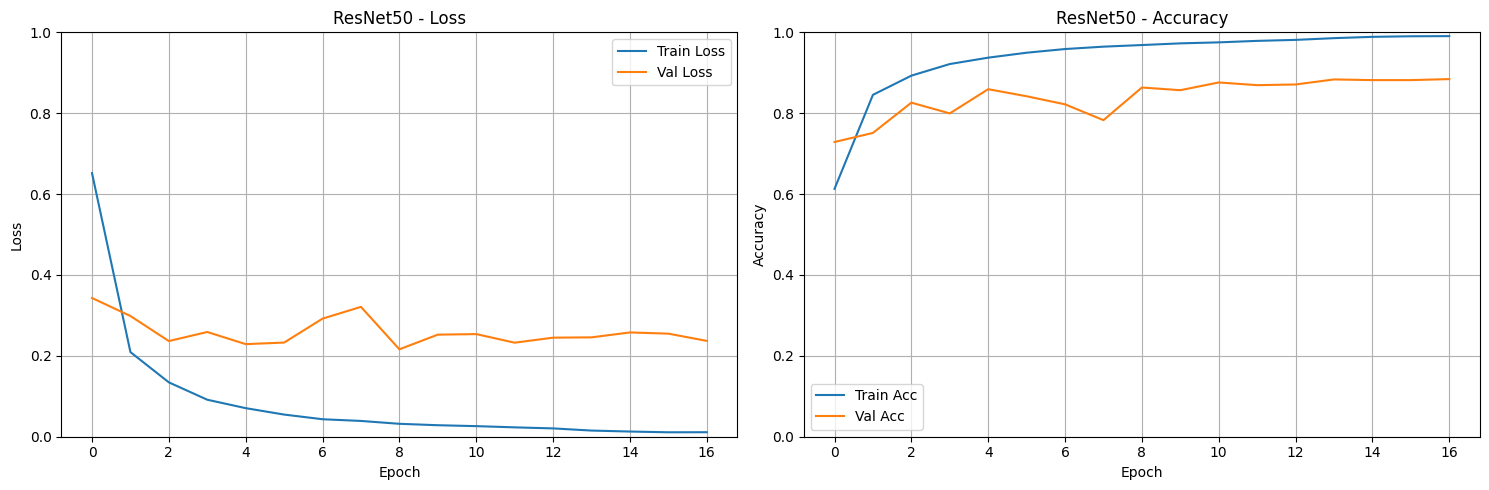

In [7]:
print("--- Training History Visualization ---")
plot_training_history(history_storage)

In [8]:
import pickle
import os

# Tên file bạn muốn lưu
file_name = 'training_history_storage.pkl'

# Lưu history_storage vào file
with open(file_name, 'wb') as f:
    pickle.dump(history_storage, f)

print(f"Đã lưu history_storage vào file '{file_name}' thành công.")

Đã lưu history_storage vào file 'training_history_storage.pkl' thành công.



📊 INDIVIDUAL MODEL EVALUATION

--- Evaluating ResNet50 ---
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step

Classification Report:
              precision    recall  f1-score   support

       akiec       0.71      0.77      0.74        65
         bcc       0.87      0.84      0.86       103
         bkl       0.73      0.80      0.77       220
          df       0.90      0.83      0.86        23
         mel       0.61      0.74      0.67       223
          nv       0.96      0.91      0.93      1341
        vasc       1.00      0.96      0.98        28

    accuracy                           0.87      2003
   macro avg       0.83      0.84      0.83      2003
weighted avg       0.88      0.87      0.87      2003

Balanced Accuracy: 0.8356

Confusion Matrix:


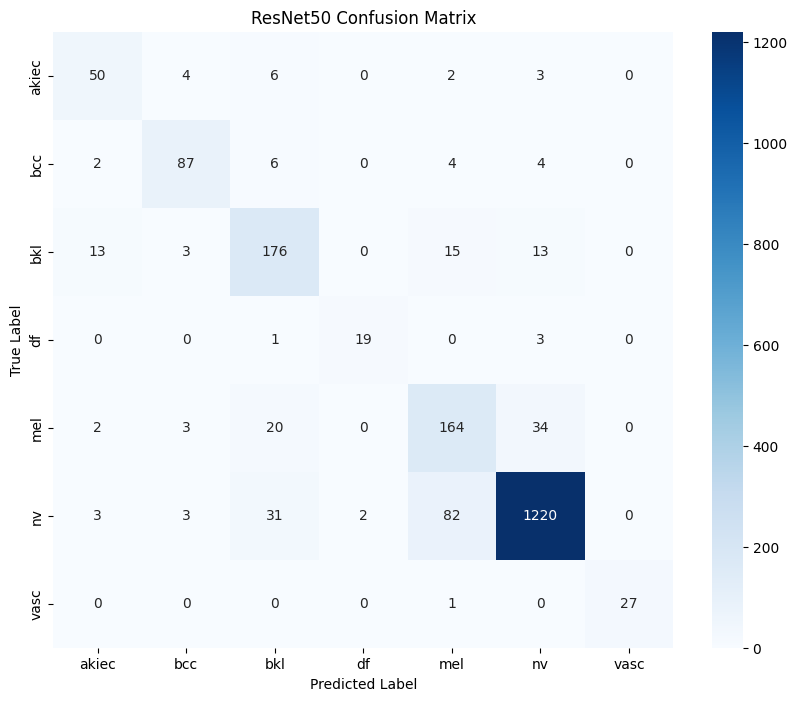

AUC (OVR): 0.9786


In [9]:
print(f"\n{'='*40}")
print(f"📊 INDIVIDUAL MODEL EVALUATION")
print(f"{'='*40}")

y_true = test_df['cell_type_idx'].values
ensemble_probs = np.zeros((len(test_df), num_classes)) ##add
classes = [idx_to_label[i] for i in range(num_classes)]

for model_name, path in saved_models_info.items():
    print(f"\n--- Evaluating {model_name} ---")
    
    # Load model
    model = tf.keras.models.load_model(path, custom_objects={'FocalLoss': FocalLoss})
    
    # Predict
    preds = model.predict(test_ds, verbose=1)
    ensemble_probs += preds # Sum probabilities #add
    y_pred = np.argmax(preds, axis=1)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    # Balanced accuracy
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    
    # Confusion matrix
    print("\nConfusion Matrix:")
    plot_confusion_matrix_custom(y_true, y_pred, classes, title=f"{model_name} Confusion Matrix")
    
    # ROC-AUC
    auc = roc_auc_score(tf.keras.utils.to_categorical(y_true, num_classes), preds, multi_class='ovr')
    print(f"AUC (OVR): {auc:.4f}")
    
    # Cleanup
    del model
    tf.keras.backend.clear_session()
    gc.collect()

# # Average Ensemble
# ensemble_probs /= len(saved_models_info)
# y_pred_ensemble = np.argmax(ensemble_probs, axis=1)

# # --- FINAL METRICS ---
# print("\n=== CLASSIFICATION REPORT ===")
# print(classification_report(y_true, y_pred_ensemble, target_names=classes))

# print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred_ensemble):.4f}")
# print(f"AUC (OVR): {roc_auc_score(tf.keras.utils.to_categorical(y_true, num_classes), ensemble_probs, multi_class='ovr'):.4f}")

# # --- PLOTS ---
# print("\n=== CONFUSION MATRIX ===")
# plot_confusion_matrix_custom(y_true, y_pred_ensemble, classes, title="Ensemble Confusion Matrix")

In [10]:
# # Lưu balanced accuracy của từng model trên validation set
# val_scores = {}

# for model_name, path in saved_models_info.items():
#     model = tf.keras.models.load_model(path, custom_objects={'FocalLoss': FocalLoss})
#     preds_val = model.predict(val_ds, verbose=0)
#     y_val_pred = np.argmax(preds_val, axis=1)
#     y_val_true = val_df['cell_type_idx'].values
#     score = balanced_accuracy_score(y_val_true, y_val_pred)
#     val_scores[model_name] = score
#     del model
#     tf.keras.backend.clear_session()
#     gc.collect()

# # Chuyển metric thành trọng số
# total_score = sum(val_scores.values())
# weights_auto = {k: v/total_score for k, v in val_scores.items()}
# print("Auto weights:", weights_auto)

# # --- Weighted Averaging với trọng số tự động ---
# ensemble_probs_auto = np.zeros((len(test_df), num_classes))

# for model_name, path in saved_models_info.items():
#     weight = weights_auto[model_name]
#     model = tf.keras.models.load_model(path, custom_objects={'FocalLoss': FocalLoss})
#     preds = model.predict(test_ds, verbose=1)
#     ensemble_probs_auto += preds * weight
#     del model
#     tf.keras.backend.clear_session()
#     gc.collect()

# y_pred_auto = np.argmax(ensemble_probs_auto, axis=1)
# print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred_auto))


In [11]:
# print(f"\n{'='*40}")
# print(f"📊 ENSEMBLE EVALUATION (Simple & Weighted Averaging)")
# print(f"{'='*40}")

# y_true = test_df['cell_type_idx'].values
# classes = [idx_to_label[i] for i in range(num_classes)]

# # --- 1. SIMPLE AVERAGING ---
# ensemble_probs_simple = np.zeros((len(test_df), num_classes))

# for model_name, path in saved_models_info.items():
#     print(f"Loading {model_name} for Simple Averaging...")
#     model = tf.keras.models.load_model(path, custom_objects={'FocalLoss': FocalLoss})
#     preds = model.predict(test_ds, verbose=1)
#     ensemble_probs_simple += preds
#     del model
#     tf.keras.backend.clear_session()
#     gc.collect()

# ensemble_probs_simple /= len(saved_models_info)
# y_pred_simple = np.argmax(ensemble_probs_simple, axis=1)

# print("\n=== SIMPLE AVERAGING ===")
# print(classification_report(y_true, y_pred_simple, target_names=classes))
# print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred_simple):.4f}")
# print(f"AUC (OVR): {roc_auc_score(tf.keras.utils.to_categorical(y_true, num_classes), ensemble_probs_simple, multi_class='ovr'):.4f}")
# plot_confusion_matrix_custom(y_true, y_pred_simple, classes, title="Simple Averaging Confusion Matrix")
# plot_multiclass_roc(y_true, ensemble_probs_simple, classes, title="Simple Averaging ROC Curves")

# # --- 2. WEIGHTED AVERAGING TỰ ĐỘNG ---
# # weights_auto là dict được tính trước dựa trên balanced accuracy trên val set
# # Ví dụ: weights_auto = {'EfficientNetB3':0.35, 'ResNet50':0.25, 'DenseNet121':0.25, 'Xception':0.15}

# ensemble_probs_weighted = np.zeros((len(test_df), num_classes))

# for model_name, path in saved_models_info.items():
#     weight = weights_auto.get(model_name, 1.0/len(saved_models_info))  # fallback nếu model không có trong dict
#     print(f"Loading {model_name} for Weighted Averaging (weight={weight:.3f})...")
#     model = tf.keras.models.load_model(path, custom_objects={'FocalLoss': FocalLoss})
#     preds = model.predict(test_ds, verbose=1)
#     ensemble_probs_weighted += preds * weight
#     del model
#     tf.keras.backend.clear_session()
#     gc.collect()

# y_pred_weighted = np.argmax(ensemble_probs_weighted, axis=1)

# print("\n=== WEIGHTED AVERAGING (TỰ ĐỘNG) ===")
# print(classification_report(y_true, y_pred_weighted, target_names=classes))
# print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred_weighted):.4f}")
# print(f"AUC (OVR): {roc_auc_score(tf.keras.utils.to_categorical(y_true, num_classes), ensemble_probs_weighted, multi_class='ovr'):.4f}")

# plot_confusion_matrix_custom(y_true, y_pred_weighted, classes, title="Weighted Averaging Confusion Matrix")
# plot_multiclass_roc(y_true, ensemble_probs_weighted, classes, title="Weighted Averaging ROC Curves")


In [12]:
# submission = pd.DataFrame({
#     'image_id': test_df['image_id'],
#     'true_label': test_df['dx'],
#     'pred_label': [idx_to_label[i] for i in y_pred_ensemble]
# })

# # Thêm cột xác suất
# for i, label in idx_to_label.items():
#     submission[f'prob_{label}'] = ensemble_probs[:, i]

# save_path = "ensemble_predictions.csv"
# submission.to_csv(save_path, index=False)
# print(f"✅ Results saved to {save_path}")

In [13]:
# import json
# import os

# # --- Lưu weights ra file JSON ---
# weights_path = os.path.join(cfg.MODEL_SAVE_DIR, "ensemble_weights.json")
# with open(weights_path, 'w') as f:
#     json.dump(weights_auto, f)
# print(f"✅ Ensemble weights saved at {weights_path}")

# # # --- Load lại weights khi cần ---
# # with open(weights_path, 'r') as f:
# #     loaded_weights = json.load(f)
# # print("✅ Loaded weights:", loaded_weights)
